In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ast import literal_eval
from collections import Counter
pd.set_option('display.max_columns', None)
import ast

In [2]:
import scipy.sparse as sp
import joblib

In [3]:
from sklearn.preprocessing import normalize

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer
from scipy.sparse import hstack, csr_matrix
from sklearn.neighbors import NearestNeighbors


/Users/filimono/Documents/Coding/RecSys/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df = pd.read_csv('../data/movies_DB.csv')

In [10]:
ratings = pd.read_csv('../data/ratings.csv')

In [22]:
ratings[ratings['movieId'] == 1].median()

userId       3.530000e+02
movieId      1.000000e+00
rating       4.000000e+00
timestamp    1.079098e+09
dtype: float64

In [17]:
ratings['movieId'].value_counts()

movieId
356      341
296      324
318      311
593      304
260      291
        ... 
64997      1
72380      1
129        1
4736       1
6425       1
Name: count, Length: 9066, dtype: int64

In [6]:
drop_features = ['movie_id', 'title', 'poster_url', 'poster_urls', 'video_keys', 'external_ids']
embeddings_features = ['overview','tagline', 'review_texts']
tf_idf_features = ['genres', 'keywords', 'director', 'certification', 'cast']
num_features = ['release_date', 'runtime', 'popularity', 'budget', 'revenue']

In [9]:
df.head(52)

,movie_id,title,overview,genres,keywords,director,release_date,runtime,popularity,poster_url,budget,revenue,tagline,poster_urls,video_keys,review_texts,external_ids,certification,cast
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","['Family', 'Comedy', 'Animation', 'Adventure']","['rescue', 'friendship', 'mission', 'jealousy'...",John Lasseter,1995-11-22,81,18.5540,https://image.tmdb.org/t/p/w500/uXDfjJbdP4ijW5...,30000000,394436586,The adventure takes off when toys come to life!,['https://image.tmdb.org/t/p/w500/uXDfjJbdP4ij...,"['_hIfuYVgBrY', 'TZOCUtoygtc', 'CxwTLktovTU', ...","[""This movie came out when I was three. Now I'...","{'id': 862, 'imdb_id': 'tt0114709', 'wikidata_...",G,"[{'name': 'Tom Hanks', 'profile_url': 'https:/..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"['Adventure', 'Fantasy', 'Family']","['giant insect', 'board game', 'disappearance'...",Joe Johnston,1995-12-15,104,2.5713,https://image.tmdb.org/t/p/w500/iWV47r6kFneCiA...,65000000,262821940,It's a jungle in here.,['https://image.tmdb.org/t/p/w500/nLXYV4WmYUF4...,"['aPkVamOQzVQ', 'BBu-chLYTJ8', '1xKR759ghEw', ...","[""Throw the dice and take a turn, Jumanji made...","{'id': 8844, 'imdb_id': 'tt0113497', 'wikidata...",PG,"[{'name': 'Robin Williams', 'profile_url': 'ht..."
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"['Romance', 'Comedy']","['fishing', 'sequel', 'old man', 'best friend'...",Howard Deutch,1995-12-22,101,2.5156,https://image.tmdb.org/t/p/w500/1FSXpj5e8l4KH6...,25000000,71500000,Still Yelling. Still Fighting. Still Ready for...,['https://image.tmdb.org/t/p/w500/1FSXpj5e8l4K...,['rEnOoWs3FuA'],[],"{'id': 15602, 'imdb_id': 'tt0113228', 'wikidat...",PG-13,"[{'name': 'Walter Matthau', 'profile_url': 'ht..."
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","['Comedy', 'Drama', 'Romance']","['based on novel or book', 'single mother', 'd...",Forest Whitaker,1995-12-22,127,3.4707,https://image.tmdb.org/t/p/w500/qJU6rfil5xLVb5...,16000000,81452156,Friends are the people who let you be yourself...,['https://image.tmdb.org/t/p/w500/afLVNPUxvBZ5...,['j9xml1CxgXI'],[],"{'id': 31357, 'imdb_id': 'tt0114885', 'wikidat...",R,"[{'name': 'Whitney Houston', 'profile_url': 'h..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,"['Comedy', 'Family']","['daughter', 'baby', 'parent child relationshi...",Charles Shyer,1995-12-08,106,2.9373,https://image.tmdb.org/t/p/w500/rj4LBtwQ0uGrpB...,0,76594107,Just when his world is back to normal... he's ...,['https://image.tmdb.org/t/p/w500/rj4LBtwQ0uGr...,['yCg8WNQwe0A'],[],"{'id': 11862, 'imdb_id': 'tt0113041', 'wikidat...",PG,"[{'name': 'Steve Martin', 'profile_url': 'http..."
5,949,Heat,Obsessive master thief Neil McCauley leads a t...,"['Crime', 'Drama', 'Action']","['robbery', 'chase', 'obsession', 'detective',...",Michael Mann,1995-12-15,170,10.5781,https://image.tmdb.org/t/p/w500/umSVjVdbVwtx5r...,60000000,187400000,A Los Angeles crime saga.,['https://image.tmdb.org/t/p/w500/qT3rcAX7dV45...,"['7ntQf1Mjy-M', 'sBoQeDVsuzQ', 'FxNsFbQavx0', ...","[""You don't live with me, you live among the r...","{'id': 949, 'imdb_id': 'tt0113277', 'wikidata_...",R,"[{'name': 'Al Pacino', 'profile_url': 'https:/..."
6,11860,Sabrina,"Sabrina Fairchild, a chauffeur's daughter, gre...","['Romance', 'Drama', 'Comedy']","['chauffeur', 'sibling relationship', 'paris, ...",Sydney Pollack,1995-12-15,127,4.1330,https://image.tmdb.org/t/p/w500/i8PbLJDPU7vCww...,58000000,53672080,You are cordially invited to the most surprisi...,['https://image.tmdb.org/t/p/w500/i8PbLJDPU7vC...,"['iEqPw_QP28c', 'twTksx_lWB4']","[""**A completely dispensable remake, for many ...","{'id': 11860, 'imdb_id': 'tt0114319', 'wikidat...",PG,"[{'name': 'Harrison Ford', 'profile_url': 'htt..."
7,45325,Tom and Huck,"A mischievous young boy, Tom Sawyer, witnesses...","['Family', 'Action', 'Adventure', 'Drama']","['based on novel or bo

# Категориальные признаки

In [8]:
df.iloc[1]['genres']
[k.lower() for k in literal_eval(df.iloc[1]['genres'])]
' '.join([k.lower() for k in literal_eval(df.iloc[1]['genres'])])
df.iloc[1]['certification']

'PG'

---

## Tf-Idf

In [9]:
tf_idf_text = []

def data_to_tf_idf(df):
    for i in range(len(df)):
        parts = []
        
        genres = df.iloc[i]['genres']
        if pd.notna(genres):
            if isinstance(genres, str):
                genres = literal_eval(genres)
            clean_genres = [k.lower() for k in genres]
            parts.append(' '.join(clean_genres))
            
        keywords = df.iloc[i]['keywords']
        if pd.notna(keywords):
            if isinstance(keywords, str):
                keywords = literal_eval(keywords)
            clean_keywords = [k.lower().replace(' ', '_') for k in keywords]
            parts.append(' '.join(clean_keywords))
        
        
        director = df.iloc[i]['director']
        if pd.notna(director):
            clean_director = director.lower().replace(' ', '_')
            parts.append(clean_director)
            
        certification = df.iloc[i]['certification']
        if pd.notna(certification):
            clean_certification = certification.lower()
            parts.append(clean_certification)
            
        cast = df.iloc[i]['cast']
        if pd.notna(cast):
            if isinstance(cast, str):
                cast = ast.literal_eval(cast)
            
            clean_cast = []
            for actor in cast[:5]:  
                actor_name = actor['name'].lower().replace(' ', '_')
                clean_cast.append(actor_name)
            parts.append(' '.join(clean_cast))
        tf_idf_text.append(' '.join(parts))

    
    return tf_idf_text

In [10]:
tf_idf_text = data_to_tf_idf(df)

In [11]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2), min_df=2)
tfidf_matrix = tfidf.fit_transform(tf_idf_text)

In [12]:
tfidf_matrix.shape

(95501, 5000)

# Получаем матрицу tf-idf


In [6]:
tfidf_matrix = sp.load_npz('../data/model/matrix/tfidf_matrix.npz')

In [13]:
tf_idf_features

['genres', 'keywords', 'director', 'certification', 'cast']

In [14]:
embeddings_features

['overview', 'tagline', 'review_texts']

In [15]:
df.iloc[1]['overview']

"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures."

---

## Embeddings

Проверить мбединги

In [16]:
emb_text = []

def data_to_emb(df):
    
    for i in range(len(df)):
        
        parts = []
        if pd.notna(df.iloc[i]['overview']):
            parts.append(str(df.iloc[i]['overview']))
            
        if pd.notna(df.iloc[i]['tagline']):
            parts.append(str(df.iloc[i]['tagline']))
            
        if pd.notna(df.iloc[i]['review_texts']):
            reviews = df.iloc[i]['review_texts']
            if isinstance(reviews, str):
                try:
                    reviews = ast.literal_eval(reviews)
                except:
                    reviews = []
            if isinstance(reviews, list):
                
                for review in reviews[:3]:
                    if review and isinstance(review, str):
                        parts.append(review.strip())
        
        emb_text.append(' '.join(parts))  
    
    return emb_text
    
    

In [17]:
emb_text = data_to_emb(df)

In [18]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7570.68it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [19]:
embeddings = model.encode(emb_text, batch_size=32, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)

Batches: 100%|██████████| 2985/2985 [04:13<00:00, 11.76it/s]


In [20]:
embeddings_sparse = csr_matrix(embeddings)

In [21]:
embeddings_sparse.shape

(95501, 384)

# Получаем эмбэддинги

In [7]:
embeddings_sparse = sp.load_npz('../data/model/matrix/embeddings_sparse.npz')

----

# Числовые предикаторы

In [8]:
num_features

['release_date', 'runtime', 'popularity', 'budget', 'revenue']

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95501 entries, 0 to 95500
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   movie_id       95501 non-null  int64  
 1   title          95501 non-null  str    
 2   overview       94513 non-null  str    
 3   genres         95501 non-null  str    
 4   keywords       95501 non-null  str    
 5   director       94556 non-null  str    
 6   release_date   95467 non-null  str    
 7   runtime        95501 non-null  int64  
 8   popularity     95501 non-null  float64
 9   poster_url     94133 non-null  str    
 10  budget         95501 non-null  int64  
 11  revenue        95501 non-null  int64  
 12  tagline        44485 non-null  str    
 13  poster_urls    95501 non-null  str    
 14  video_keys     95501 non-null  str    
 15  review_texts   95501 non-null  str    
 16  external_ids   95501 non-null  str    
 17  certification  34800 non-null  str    
 18  cast           95

In [10]:
df['release_date']

0        1995-11-22
1        1995-12-15
2        1995-12-22
3        1995-12-22
4        1995-12-08
            ...    
95496    2025-02-13
95497    2025-05-17
95498    2025-06-09
95499    2025-03-21
95500    2025-10-28
Name: release_date, Length: 95501, dtype: str

In [11]:
df['year'] = df['release_date'].apply(lambda x: int(x.split('-')[0]) if isinstance(x, str) else 0)

In [25]:
num_features

['release_date', 'runtime', 'popularity', 'budget', 'revenue']

In [26]:
num_features.append('year')

In [27]:
num_features

['release_date', 'runtime', 'popularity', 'budget', 'revenue', 'year']

In [28]:
num_features.remove('release_date')

In [29]:
num_features

['runtime', 'popularity', 'budget', 'revenue', 'year']

In [12]:
df['runtime'].value_counts()

runtime
90     5118
95     2868
100    2763
93     2398
85     2343
       ... 
311       1
504       1
230       1
323       1
440       1
Name: count, Length: 337, dtype: int64

In [13]:
df.loc[72444, 'runtime'] = 1000

<Axes: ylabel='runtime'>

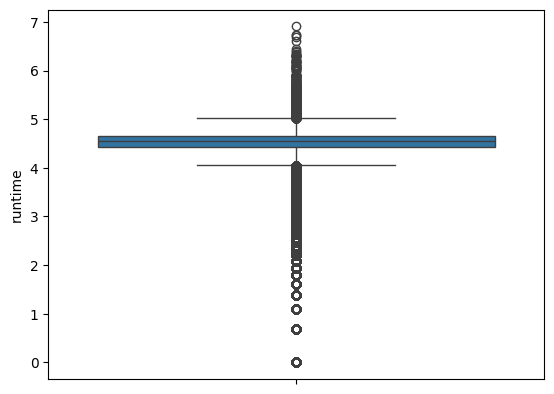

In [14]:
sns.boxplot(np.log1p(df['runtime']))

(0.0, 250.0)

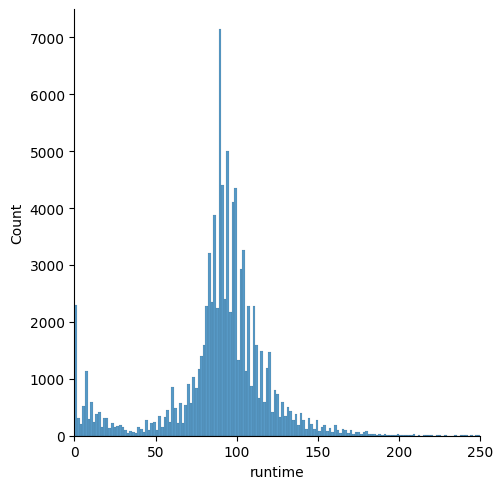

In [15]:
sns.displot(df['runtime'])
plt.xlim(0, 250)

In [16]:
df['popularity'].value_counts()

popularity
0.0143    242
0.0214    148
0.0071    145
0.0286    109
0.0000     96
         ... 
2.1088      1
1.9246      1
1.2084      1
0.6004      1
1.2442      1
Name: count, Length: 39349, dtype: int64

In [17]:
df[df['popularity'] > 300]

,movie_id,title,overview,genres,keywords,director,release_date,runtime,popularity,poster_url,budget,revenue,tagline,poster_urls,video_keys,review_texts,external_ids,certification,cast,year
91197,798645,The Running Man,"Desperate to save his sick daughter, working-c...","['Action', 'Thriller', 'Science Fiction']","['based on novel or book', 'dark comedy', 'sur...",Edgar Wright,2025-11-11,133,446.1148,https://image.tmdb.org/t/p/w500/dKL78O9zxczVgj...,110000000,68391082,Hunt him down.,['https://image.tmdb.org/t/p/w500/dKL78O9zxczV...,"['xMevjkItihw', 'Wp9P7EhSN5Q', 'VrUNH9pe1cY', ...",['FULL SPOILER-FREE REVIEW @ movieswetextedabo...,"{'id': 798645, 'imdb_id': 'tt14107334', 'wikid...",R,"[{'name': 'Glen Powell', 'profile_url': 'https...",2025
91198,1084242,Zootopia 2,After cracking the biggest case in Zootopia's ...,"['Animation', 'Comedy', 'Adventure', 'Family',...","['snake', 'bunny', 'fox', 'cop', 'sequel', 'an...",Jared Bush,2025-11-26,107,392.3259,https://image.tmdb.org/t/p/w500/oJ7g2CifqpStmo...,150000000,1137444817,Zootopia will be changed furrrever...,['https://image.tmdb.org/t/p/w500/ib6v6qUXzez1...,"['Op-5HjO5Txw', 'uKixOcSvvY8', '5H7L9j0dW90', ...",['FULL SPOILER-FREE REVIEW @ https://movieswet...,"{'id': 1084242, 'imdb_id': 'tt26443597', 'wiki...",PG,"[{'name': 'Ginnifer Goodwin', 'profile_url': '...",2025
91199,812583,Wake Up Dead Man: A Knives Out Mystery,When young priest Jud Duplenticy is sent to as...,"['Thriller', 'Mystery', 'Comedy']","['detective', 'investigation', 'sequel', 'murd...",Rian Johnson,2025-11-26,145,348.3879,https://image.tmdb.org/t/p/w500/qCOGGi8JBVEZMc...,210000000,4000000,He works in mysterious ways.,['https://image.tmdb.org/t/p/w500/qCOGGi8JBVEZ...,"['1FZFlZUj4tQ', '_r0Y1feGM24', 'zl7oD1Ot0fM', ...",['FULL SPOILER-FREE REVIEW @ https://fandomwir...,"{'id': 812583, 'imdb_id': 'tt14364480', 'wikid...",PG-13,"[{'name': 'Daniel Craig', 'profile_url': 'http...",2025


<Axes: ylabel='popularity'>

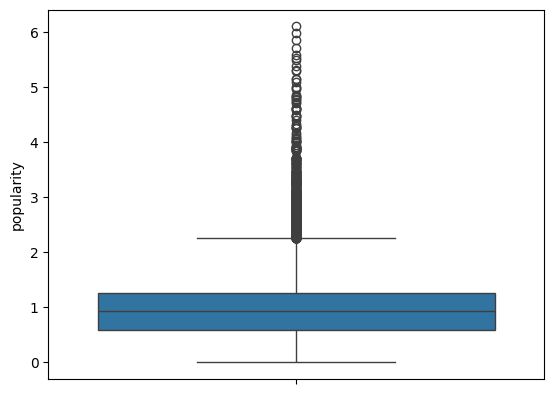

In [42]:
sns.boxplot(np.log1p(df['popularity']))

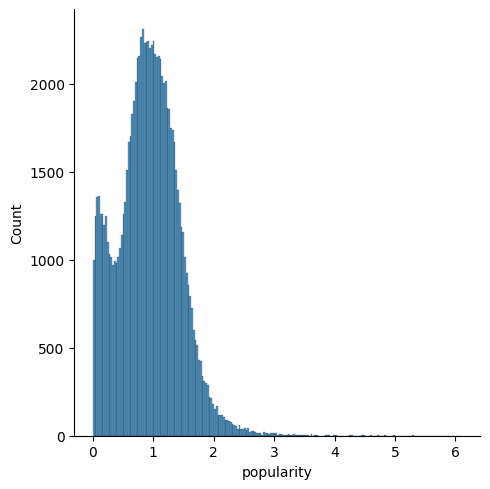

In [44]:
sns.displot(np.log1p(df['popularity']))

In [45]:
df['budget'].value_counts()

budget
0           78434
10000000      499
5000000       485
1000000       449
2000000       445
            ...  
1850            1
5400            1
668240          1
360             1
10673500        1
Name: count, Length: 2564, dtype: int64

In [46]:
78434 / 95501 * 100

82.12898294258699

<Axes: ylabel='budget'>

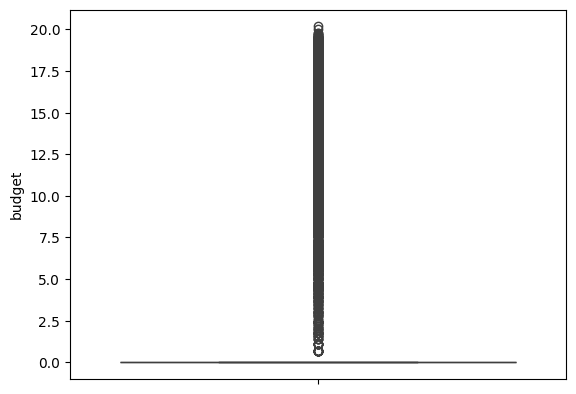

In [48]:
sns.boxplot(np.log1p(df['budget']))

In [18]:
df['revenue'].value_counts()

revenue
0           78928
2000000        54
10000000       50
5000000        44
1000000        44
            ...  
1068            1
58558           1
215586          1
77433           1
379705          1
Name: count, Length: 14210, dtype: int64

In [19]:
num_features

['release_date', 'runtime', 'popularity', 'budget', 'revenue']

In [31]:
df_num = df[num_features].copy()

In [32]:

df_num['popularity'] = np.log1p(df_num['popularity']) 
df_num['budget'] =  np.log1p(df_num['budget']) 
df_num['revenue']=  np.log1p(df_num['revenue']) 

In [33]:
scaler = StandardScaler()

In [34]:
df_num.info()

<class 'pandas.DataFrame'>
RangeIndex: 95501 entries, 0 to 95500
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   runtime     95501 non-null  int64  
 1   popularity  95501 non-null  float64
 2   budget      95501 non-null  float64
 3   revenue     95501 non-null  float64
 4   year        95501 non-null  int64  
dtypes: float64(3), int64(2)
memory usage: 3.6 MB


In [35]:
num_normalized = scaler.fit_transform(df_num)

In [36]:
num_sparse = csr_matrix(num_normalized)

In [65]:
num_sparse.shape

(95501, 5)

---

# Модель

In [37]:
weight_num = 1.0
weight_tfidf = 1.0
weight_emb = 1.0

feature_matrix = hstack([
    weight_num * num_sparse,
    weight_tfidf * tfidf_matrix,
    weight_emb * embeddings_sparse
])


In [40]:
feature_matrix_normalized = normalize(feature_matrix, norm='l2')

In [42]:
feature_matrix_normalized.shape

(95501, 5389)

In [41]:
knn_model = NearestNeighbors(
    n_neighbors=20,      
    metric='cosine',    
    algorithm='auto',
    n_jobs=-1           
)

knn_model.fit(feature_matrix_normalized)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1


---

# Meta data

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95501 entries, 0 to 95500
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   movie_id       95501 non-null  int64  
 1   title          95501 non-null  str    
 2   overview       94513 non-null  str    
 3   genres         95501 non-null  str    
 4   keywords       95501 non-null  str    
 5   director       94556 non-null  str    
 6   release_date   95467 non-null  str    
 7   runtime        95501 non-null  int64  
 8   popularity     95501 non-null  float64
 9   poster_url     94133 non-null  str    
 10  budget         95501 non-null  int64  
 11  revenue        95501 non-null  int64  
 12  tagline        44485 non-null  str    
 13  poster_urls    95501 non-null  str    
 14  video_keys     95501 non-null  str    
 15  review_texts   95501 non-null  str    
 16  external_ids   95501 non-null  str    
 17  certification  34800 non-null  str    
 18  cast           95

In [44]:
df.head(1)

,movie_id,title,overview,genres,keywords,director,release_date,runtime,popularity,poster_url,budget,revenue,tagline,poster_urls,video_keys,review_texts,external_ids,certification,cast,year
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","['Family', 'Comedy', 'Animation', 'Adventure']","['rescue', 'friendship', 'mission', 'jealousy'...",John Lasseter,1995-11-22,81,18.554,https://image.tmdb.org/t/p/w500/uXDfjJbdP4ijW5...,30000000,394436586,The adventure takes off when toys come to life!,['https://image.tmdb.org/t/p/w500/uXDfjJbdP4ij...,"['_hIfuYVgBrY', 'TZOCUtoygtc', 'CxwTLktovTU', ...","[""This movie came out when I was three. Now I'...","{'id': 862, 'imdb_id': 'tt0114709', 'wikidata_...",G,"[{'name': 'Tom Hanks', 'profile_url': 'https:/...",1995


In [45]:
meta = ['title', 'director', 'release_date', 'movie_id', 'poster_url', 'poster_urls', 'video_keys']

In [51]:
metadata_model = df[['movie_id', 'title']].copy()
metadata_frontend = df[['movie_id', 'title', 'poster_url', 'poster_urls', 'video_keys', 'release_date', 'director']].copy()

# Сохранение трансформеров + матриц

In [47]:
sp.save_npz('../data/model/matrix/tfidf_matrix.npz', tfidf_matrix)

In [48]:
sp.save_npz('../data/model/matrix/embeddings_sparse.npz', embeddings_sparse)

In [49]:
sp.save_npz('../data/model/matrix/num_sparse.npz', num_sparse)

In [50]:
sp.save_npz('../data/model/matrix/feature_matrix.npz', feature_matrix_normalized)

In [54]:
joblib.dump(metadata_model, '../data/model/meta/metadata_model.joblib')
joblib.dump(metadata_frontend, '../data/model/meta/metadata_frontend.joblib')

['../data/model/meta/metadata_frontend.joblib']

In [55]:

#joblib.dump(tfidf, '../data/model/transformers/tfidf_vectorizer.joblib')      
joblib.dump(scaler, '../data/model/transformers/scaler.joblib')               
#joblib.dump(model, '../data/model/transformers/embedding_model.joblib')       
joblib.dump(knn_model, '../data/model/transformers/knn_model.joblib')          



['../data/model/transformers/knn_model.joblib']